<a href="https://colab.research.google.com/github/guupiii/ESAA/blob/main/ESAA_OB_week5_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **2.4 파이토치 코드 맛보기**

1. price(지동차 가격)
2. maint(지동차 유지 비용)
3. doors(자동차 문 개수)
4. persons(수용 인원)
5. lug_capacity(수하물 용량)
6. safety(안전성)
7. output(차상태):

먼저 필요한 라이브러리를 설치합니다.

In [96]:
!pip install --upgrade matplotlib --use-feature=2020-resolver
!pip install --upgrade seaborn --use-feature=2020-resolver
!pip install --upgrade scikit-learn --use-feature=2020-resolver


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

option --use-feature: invalid choice: '2020-resolver' (choose from 'fast-deps', 'truststore', 'no-binary-enable-wheel-cache')

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

option --use-feature: invalid choice: '2020-resolver' (choose from 'fast-deps', 'truststore', 'no-binary-enable-wheel-cache')

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [opti

In [97]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [98]:
from google.colab import drive
drive.mount('/content/drive')
dataset = pd.read_csv('/content/drive/MyDrive/MLData/car_evaluation.csv')
dataset.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


컴퓨터는 인간의 언어인 단어를 인식할 수 없기 때문에 단어를 벡터로 바꾸어 주는 임베딩 처리가 필요합니다.

주어진 데이터셋을 이해하기 쉽도록 분포 형태로 시각화하여 표현하면 다음과 같습니다.

<Axes: ylabel='count'>

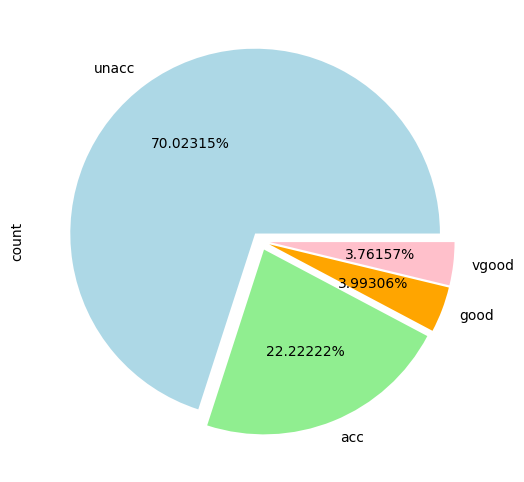

In [99]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8
fig_size[1] = 6
plt.rcParams["figure.figsize"] = fig_size
dataset.output.value_counts().plot(kind='pie', autopct='%0.05f%%', colors=['lightblue', 'lightgreen', 'orange', 'pink'], explode=(0.05, 0.05, 0.05,0.05))

양호한 상태의 자동차 비율이 매우 낮습니다.

딥러닝은 통계 알고리즘을 기반으로 하기 때문에 단어를 숫자로 변환해야 합니다.. 가장 먼저 필요한 전처리는 데이터를 파악하는 것입니다. 주어진 데이터의 형태를 파악한 후 숫자로 변환해 주어야 하는데, 예제에서 다루는 데이터의 칼럼들은 모두 범주형 데이터로 구성되어 있습니다.

이제 분석하기 좋게 데이터를 고치는 데이터 전처리를 해야 합니다. 먼저 astype() 메서드를 이용하여 범주 특성을 갖는 데이터를 범주형타입으로 변환합니다. 또한， 파이토치를 이용한 모델 학습을 해야 하므로 범주형 타입을 텐서로 변환해야 합니다.

In [100]:
categorical_columns = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety']

for category in categorical_columns:
    dataset[category] = dataset[category].astype('category')

price = dataset['price'].cat.codes.values
maint = dataset['maint'].cat.codes.values
doors = dataset['doors'].cat.codes.values
persons = dataset['persons'].cat.codes.values
lug_capacity = dataset['lug_capacity'].cat.codes.values
safety = dataset['safety'].cat.codes.values

categorical_data = np.stack([price, maint, doors, persons, lug_capacity, safety], 1)
categorical_data[:10]

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

범주형 데이터를 텐서로 변환하기 위해 다음과 같은 절차가 필요합니다.

범주형 데이터 > dataset[category] > 넘파이 배열 > 텐서

즉， 파이토치로 모델을 학습시카기 위해서는 텐서 형태로 변환해야하는데， 넘파이 배열을 통해
텐서를 생성할 수 있습니다.

범주형 데이터(단어)를 숫자(넘파이 배열)로 변환하기 위해 cat.codes를 시용합니다. cat.codes 는 어떤 클래스가 어떤 숫자로 매핑되어 있는지 확인이 어려운 단점이 있으므로 주의해서 사용해야합니다.

In [101]:
categorical_data = torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

In [102]:
outputs = pd.get_dummies(dataset.output)
outputs = outputs.values
outputs = torch.tensor(outputs).flatten()

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


get_dummies는 가변수(dummy variable)로 만들어 주는 함수입니다. 가변수로 만들어 준다는 의미는 문자를 숫자 (0, 1)로 바꾸어 준다는 의미입니다.

워드 임베딩은 유사한 단어끼리 유사하게 인코딩되도록 표현하는 방법입니다. 또한， 높은 차원의
임베딩일수록 단어 간의 세부적인 관계를 잘 파악할 수 있습니다. 따라서 단일 숫자로 변환된 넘파이 배열을 N차원으로 변경하여 사용합니다.

In [103]:
categorical_column_sizes = [len(dataset[column].cat.categories) for column in categorical_columns]
categorical_embedding_sizes = [(col_size, min(50, (col_size+1)//2)) for col_size in categorical_column_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [104]:
total_records = 1728
test_records = int(total_records * .2)

categorical_train_data = categorical_data[:total_records-test_records]
categorical_test_data = categorical_data[total_records-test_records:total_records]
train_outputs = outputs[:total_records-test_records]
test_outputs = outputs[total_records-test_records:total_records]

In [105]:
print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


In [106]:
class Model(nn.Module):
    def __init__(self, embedding_size, output_size, layers, p=0.4):
        super().__init__()
        self.all_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni, nf in embedding_size])
        self.embedding_dropout = nn.Dropout(p)

        all_layers = []
        num_categorical_cols = sum((nf for ni, nf in embedding_size))
        input_size = num_categorical_cols

        for i in layers:
            all_layers.append(nn.Linear(input_size, i))
            all_layers.append(nn.ReLU(inplace=True))
            all_layers.append(nn.BatchNorm1d(i))
            all_layers.append(nn.Dropout(p))
            input_size = i

        all_layers.append(nn.Linear(layers[-1], output_size))
        self.layers = nn.Sequential(*all_layers)

    def forward(self, x_categorical):
        embeddings = []
        for i,e in enumerate(self.all_embeddings):
            embeddings.append(e(x_categorical[:,i]))
        x = torch.cat(embeddings, 1)
        x = self.embedding_dropout(x)
        x = self.layers(x)
        return x

클래스 형태로 구현되는 모델은 nn.Module을 상속받습니다.

self : 첫 번째 파라미터는 self를 지정해야 하며 자기 자신을 의미합니다. 예를 들어 ex라는 함수가 있을 때 self 의미는 다음 그림과 같스빈다.

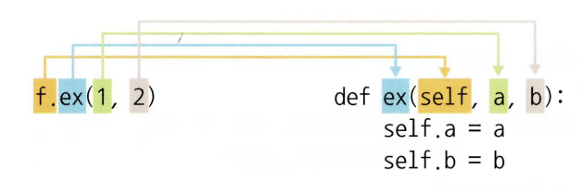

모델 훈련을 위해 앞에서 정의했던 Model 클래스의 객체를 생성합니다. 객제를 생성하면서 (범주형 칼럼의 임베딩 크기 출력 크기 은닉층의 뉴런, 드롭아웃)을 전달합니다.

In [107]:
model = Model(categorical_embedding_sizes, 4, [200,100,50], p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


모델을 훈련시키기 전에 손실 함수와 옵티마이저에 대해 정의해야 합니다. 이번 예제는 데이터를 분류해야하는 것으로 크로스 엔트로피 손실함수를 사용합니다. 또한, 옵티마이저로는 아담을 사용합니다.

In [108]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [109]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [110]:
epochs = 500
aggregated_losses = []
train_outputs = train_outputs.to(device=device, dtype=torch.int64)
for i in range(epochs):
    i += 1
    y_pred = model(categorical_train_data).to(device)
    single_loss = loss_function(y_pred, train_outputs)
    aggregated_losses.append(single_loss)

    if i%25 == 1:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

    optimizer.zero_grad()
    single_loss.backward()
    optimizer.step()

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}')

epoch:   1 loss: 1.61729431
epoch:  26 loss: 1.43728852
epoch:  51 loss: 1.33468497
epoch:  76 loss: 1.23116088
epoch: 101 loss: 1.11504924
epoch: 126 loss: 0.95328897
epoch: 151 loss: 0.83141375
epoch: 176 loss: 0.73234159
epoch: 201 loss: 0.70201588
epoch: 226 loss: 0.65029752
epoch: 251 loss: 0.63616616
epoch: 276 loss: 0.61841673
epoch: 301 loss: 0.61041969
epoch: 326 loss: 0.60064644
epoch: 351 loss: 0.59597385
epoch: 376 loss: 0.58415347
epoch: 401 loss: 0.58471763
epoch: 426 loss: 0.57734877
epoch: 451 loss: 0.57011902
epoch: 476 loss: 0.57549083
epoch: 500 loss: 0.5753481984


In [111]:
test_outputs = test_outputs.to(device=device, dtype=torch.int64)
with torch.no_grad():
    y_val = model(categorical_test_data).to(device)
    loss = loss_function(y_val, test_outputs)
print(f'Loss: {loss:.8f}')

Loss: 0.55495775


코드를 실행하면 테스트 용도의 데이터셋에 대한 손실 값을 보여 줍니다. 이 값은 훈련 데이터셋에서 도출된 손실 값과 비슷하므로 과적합은 발생하지 않았다고 판단할 수 있습니다.

In [112]:
print(y_val[:5])

tensor([[ 1.8190,  0.9214, -2.9509, -3.0441],
        [ 2.2923,  1.3702, -3.5885, -3.4718],
        [ 2.5481,  1.6261, -3.6663, -4.4587],
        [ 1.3259,  0.6471, -1.7086, -1.7689],
        [ 2.4472,  1.4977, -4.5084, -4.5724]], device='cuda:0')


In [113]:
y_val = np.argmax(y_val.cpu().numpy(), axis=1)
print(y_val[:5])

[0 0 0 0 0]


In [114]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

test_outputs=test_outputs.cpu().numpy()
print(confusion_matrix(test_outputs,y_val))
print(classification_report(test_outputs,y_val))
print(accuracy_score(test_outputs,y_val))

[[259   0]
 [ 86   0]]
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       259
           1       0.00      0.00      0.00        86

    accuracy                           0.75       345
   macro avg       0.38      0.50      0.43       345
weighted avg       0.56      0.75      0.64       345

0.7507246376811594
